## ✅ Method to Auto-Detect Non-Closed Contours in Masks
🔍 Key idea:

When using cv2.findContours, closed contours should loop back to the starting point. If they’re broken (due to annotation errors), OpenCV will return multiple fragmented contours instead of one whole contour.

In [33]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
mask_path = "../imgs/033_fibrosis_044_mask.png"
mask_path = "../imgs/033_fibrosis_119_mask.png"

img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_vis = np.zeros_like(img)
cv2.drawContours(contour_vis, contours, -1, (255, 255, 255), 2)

# Detect suspect contours using contour properties
# broken_contours = []
# for cnt in contours:
#     # Check if contour is too short or jagged (could indicate a broken shape)
#     arc_len = cv2.arcLength(cnt, closed=True)
#     approx = cv2.approxPolyDP(cnt, epsilon=0.01 * arc_len, closed=True)

#     if not cv2.isContourConvex(approx) and len(cnt) < 100:
#         broken_contours.append(cnt)

def is_contour_closed(cnt, tolerance=10):
    dist = np.linalg.norm(cnt[0][0] - cnt[-1][0])
    return dist < tolerance

broken_contours = [cnt for cnt in contours if not is_contour_closed(cnt)]
        
img_vis = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_vis, broken_contours, -1, (0, 0, 255), 2);



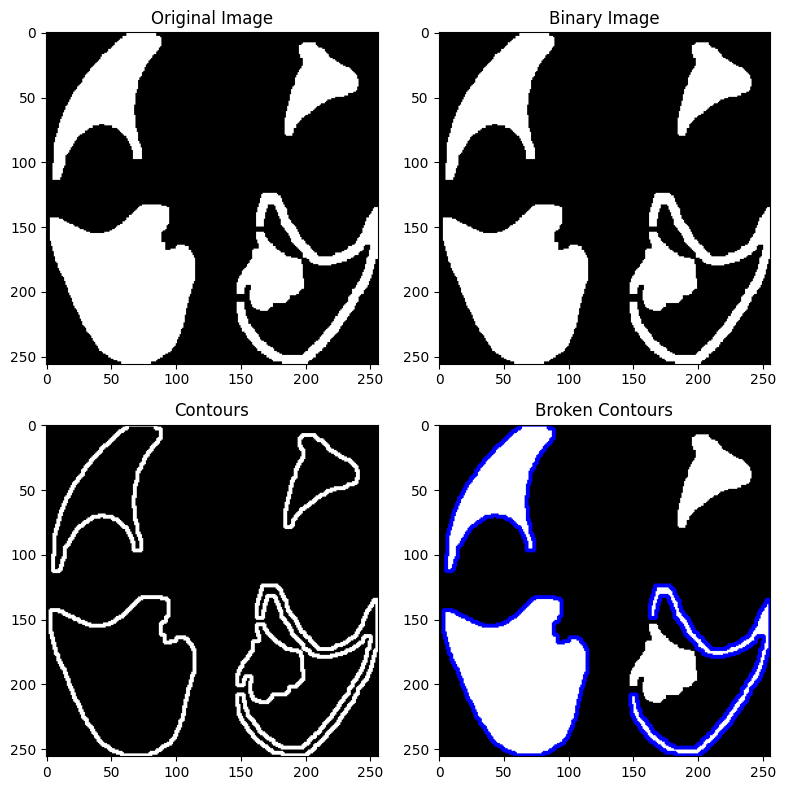

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax[0,0].set_title('Original Image')
ax[0,0].imshow(img, cmap='gray')
ax[0,1].set_title('Binary Image')
ax[0,1].imshow(binary, cmap='gray')

ax[1,0].set_title('Contours')
ax[1,0].imshow(contour_vis, cmap = 'gray')
ax[1,1].set_title('Broken Contours')
ax[1,1].imshow(img_vis)
plt.tight_layout()


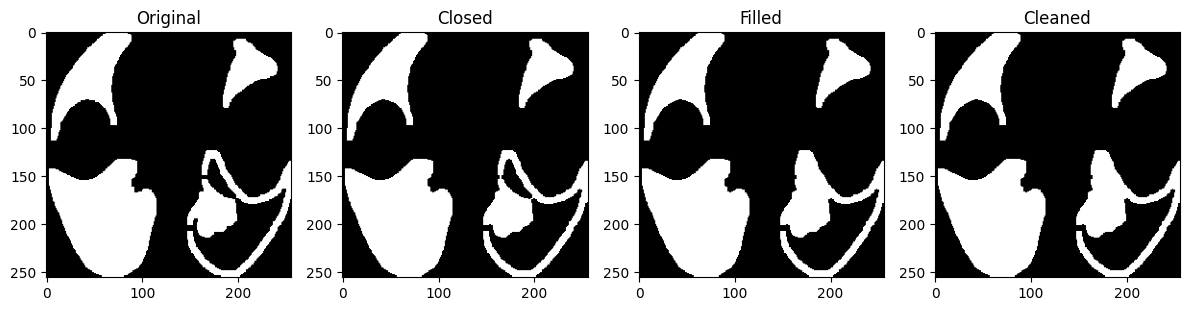

In [38]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
mask_path = "../imgs/033_fibrosis_044_mask.png"
mask_path = "../imgs/033_fibrosis_119_mask.png"

img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Morphological closing to try bridging gaps in contours
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
# kernel = np.ones((5, 5), np.uint8)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

# Fill the closed areas
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled = np.zeros_like(binary)
cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)

# Optional: clean tiny regions (remove noise)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(filled)
cleaned = np.zeros_like(filled)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] > 100:  # area threshold
        cleaned[labels == i] = 255

# Show all steps
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1); plt.title("Original"); plt.imshow(binary, cmap='gray')
plt.subplot(1, 4, 2); plt.title("Closed"); plt.imshow(closed, cmap='gray')
plt.subplot(1, 4, 3); plt.title("Filled"); plt.imshow(filled, cmap='gray')
plt.subplot(1, 4, 4); plt.title("Cleaned"); plt.imshow(cleaned, cmap='gray')
plt.tight_layout(); plt.show()